In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm

In [19]:
df = pd.read_csv('spread_features.csv', index_col='datetime', parse_dates=['datetime']).dropna()
print(df.keys())
df

Index(['month_sin', 'dayofweek_sin', 'dayofmonth_sin', 'Gas', 'Solar', 'Wind',
       'da_price', 'rt_price', 'Biomass', 'Coal', 'Gas-CC', 'Hydro', 'Nuclear',
       'Other', 'spread'],
      dtype='object')


,month_sin,dayofweek_sin,dayofmonth_sin,Gas,Solar,Wind,da_price,rt_price,Biomass,Coal,Gas-CC,Hydro,Nuclear,Other,spread
datetime,,,,,,,,,,,,,,,
2017-01-02 00:00:00-06:00,0.0,0.000000,0.201299,-0.346255,-0.029213,-0.838159,0.020396,0.192566,0.358526,1.959502,-1.263745,-0.183323,0.106358,0.001239,-0.0150
2017-01-02 01:00:00-06:00,0.0,0.000000,0.201299,-0.347727,-0.029213,-0.820258,-0.064187,0.054131,0.359318,1.823436,-1.290912,-0.184739,0.106403,0.000472,-0.7450
2017-01-02 02:00:00-06:00,0.0,0.000000,0.201299,-0.348837,-0.029213,-0.787988,-0.163767,0.000731,0.358410,1.665891,-1.296186,-0.185747,0.106619,0.000326,-0.2100
2017-01-02 03:00:00-06:00,0.0,0.000000,0.201299,-0.348563,-0.029213,-0.770285,-0.173365,-0.033283,0.359223,1.547043,-1.297203,-0.185526,0.106533,0.000180,-12.7300
2017-01-02 04:00:00-06:00,0.0,0.000000,0.201299,-0.351609,-0.029213,-0.769439,-0.158968,-0.044255,0.351905,1.493932,-1.272795,-0.187826,0.107040,-0.007456,-5.9425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00-06:00,0.0,0.974928,0.000000,0.248407,-0.029210,0.311160,0.340732,0.297536,-0.852222,0.310431,0.178897,0.971900,0.079917,13.211848,1.2375
2024-12-31 20:00:00-06:00,0.0,0.974928,0.000000,-0.119629,-0.029212,0.594214,0.020396,-0.029077,-0.863046,0.018736,0.117841,0.710757,0.079454,7.699080,-5.1425
2024-12-31 21:00:00-06:00,0.0,0.974928,0.000000,-0.296313,-0.029213,1.035159,-0.410918,-0.498148,-0.776369,-0.347762,-0.120605,-0.471542,0.084041,3.740959,-3.0725


# Train

In [20]:
feature_columns = [col for col in df.columns if col!= "spread"]
X = df[feature_columns]
y = df["spread"]

# --- 3. Split Data into Training and Testing Sets ---
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")


Training set size: 56070 samples
Testing set size: 14018 samples


In [21]:
# --- 4. Initialize and Train the XGBoost Model ---
# We use XGBRegressor because we are predicting a number
model = xgb.XGBRegressor(
    n_estimators=1000,         # Number of trees (can be high, early stopping will find the best)
    learning_rate=0.05,        # How fast the model learns
    early_stopping_rounds=10,  # Stop if performance doesn't improve for 10 rounds
    n_jobs=-1                  # Use all available CPU cores
)

print("\n--- Training XGBoost Model ---")
# We fit the model on the training data
# We use the test data in eval_set to monitor for early stopping
model.fit(
    X_train, 
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False  # Set to 100 to see progress every 100 trees
)
print("Model training complete.")

# --- 5. Evaluate the Model ---
print("\n--- Evaluating Model Performance ---")
# Use the trained model to make predictions on the *test* data
y_pred = model.predict(X_test)

# Calculate common regression metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.2f} (Closer to 1.0 is better)")


--- Training XGBoost Model ---
Model training complete.

--- Evaluating Model Performance ---
Mean Absolute Error (MAE): 20.66
Root Mean Squared Error (RMSE): 126.43
R-squared (R²): 0.43 (Closer to 1.0 is better)



--- Plotting Feature Importance ---
Feature importance plot saved to 'feature_importance.png'

--- Plotting Predictions vs. Actual ---
Prediction scatter plot saved to 'predictions_vs_actual.png'


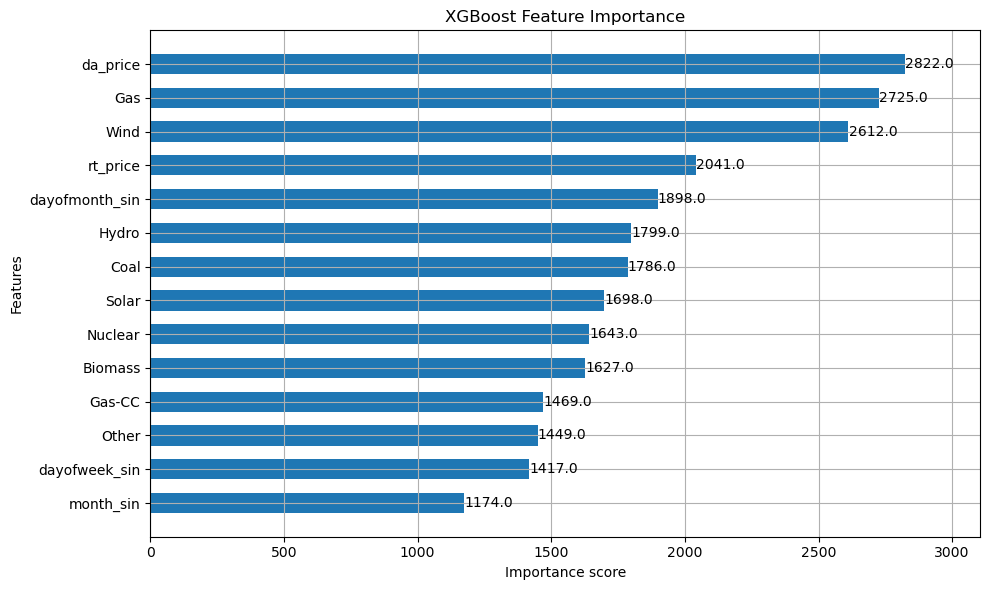

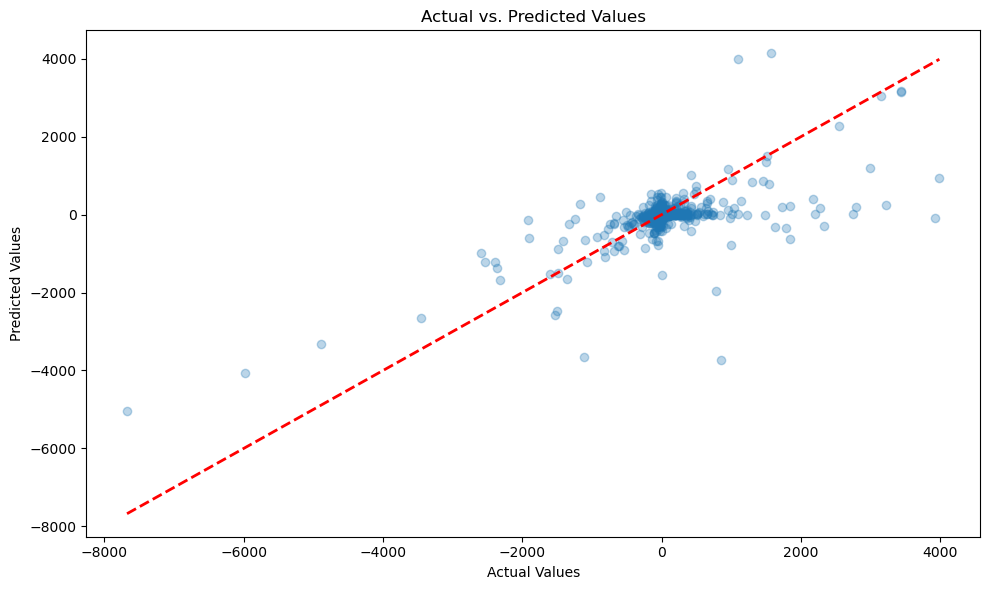

In [22]:
# --- 6. Plot Feature Importance ---
print("\n--- Plotting Feature Importance ---")
fig, ax = plt.subplots(figsize=(10, 6))
xgb.plot_importance(model, ax=ax, height=0.6)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png") # Save the plot
print("Feature importance plot saved to 'feature_importance.png'")

# --- 7. Plot Predictions vs. Actual ---
print("\n--- Plotting Predictions vs. Actual ---")
plt.figure(figsize=(10, 6))
# A scatter plot of actual (y_test) vs. predicted (y_pred)
plt.scatter(y_test, y_pred, alpha=0.3)
# A 45-degree line represents a perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.tight_layout()
plt.savefig("predictions_vs_actual.png")
print("Prediction scatter plot saved to 'predictions_vs_actual.png'")

In [205]:
def calculate_performance(y_pred, y_actual, threshold = -12):
    """
    Calculates accuracy, precision, and recall treating the problem as binary classification
    where the positive class is when the absolute value is greater than 5 (i.e., >5 or <-5).
    
    Args:
    y_pred (pd.Series or np.array): Predicted values.
    y_actual (pd.Series or np.array): Actual values.
    
    Returns:
    dict: Dictionary with accuracy, precision, and recall.
    """
    # Convert to Series if not already
    if not isinstance(y_pred, pd.Series):
        y_pred = pd.Series(y_pred)
    if not isinstance(y_actual, pd.Series):
        y_actual = pd.Series(y_actual)
    
    # Ensure same length
    if len(y_pred) != len(y_actual):
        raise ValueError("y_pred and y_actual must have the same length.")
    
    # Define positive class: |value| > threshold
    threshold = abs(threshold)
    # pred_positive = (y_pred > threshold) | (y_pred < -threshold)
    # actual_positive = (y_actual > threshold) | (y_actual < -threshold)
    pred_positive = (y_pred < -threshold) 
    actual_positive = (y_actual < -threshold) 
    
    # Calculate metrics using sklearn (labels as 1 for positive, 0 for negative)
    accuracy = accuracy_score(actual_positive, pred_positive)
    precision = precision_score(actual_positive, pred_positive, zero_division=0)
    recall = recall_score(actual_positive, pred_positive, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall
    }

performance_metrics = calculate_performance(y_pred, y_test)
print(f"\n--- Classification Performance Metrics (|value| > threshold) ---")
print(performance_metrics)


--- Classification Performance Metrics (|value| > threshold) ---
{'accuracy': 0.8868597517477529, 'precision': 0.6251441753171857, 'recall': 0.30061009428729896}


# Walk-Forward

In [196]:
df.index = pd.to_datetime(pd.to_datetime(df.index.to_series(),utc=True).dt.strftime('%Y-%m-%d %H:%M:%S'))
week_sr = df.index.to_period("W")
weeks = week_sr.unique()
df

,month_sin,dayofweek_sin,dayofmonth_sin,Gas,Solar,Wind,da_price,rt_price,Biomass,Coal,Gas-CC,Hydro,Nuclear,Other,spread
datetime,,,,,,,,,,,,,,,
2017-01-02 06:00:00,0.0,0.000000,0.201299,-0.346255,-0.029213,-0.838159,0.020396,0.192566,0.358526,1.959502,-1.263745,-0.183323,0.106358,0.001239,-0.0150
2017-01-02 07:00:00,0.0,0.000000,0.201299,-0.347727,-0.029213,-0.820258,-0.064187,0.054131,0.359318,1.823436,-1.290912,-0.184739,0.106403,0.000472,-0.7450
2017-01-02 08:00:00,0.0,0.000000,0.201299,-0.348837,-0.029213,-0.787988,-0.163767,0.000731,0.358410,1.665891,-1.296186,-0.185747,0.106619,0.000326,-0.2100
2017-01-02 09:00:00,0.0,0.000000,0.201299,-0.348563,-0.029213,-0.770285,-0.173365,-0.033283,0.359223,1.547043,-1.297203,-0.185526,0.106533,0.000180,-12.7300
2017-01-02 10:00:00,0.0,0.000000,0.201299,-0.351609,-0.029213,-0.769439,-0.158968,-0.044255,0.351905,1.493932,-1.272795,-0.187826,0.107040,-0.007456,-5.9425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01 01:00:00,0.0,0.974928,0.000000,0.248407,-0.029210,0.311160,0.340732,0.297536,-0.852222,0.310431,0.178897,0.971900,0.079917,13.211848,1.2375
2025-01-01 02:00:00,0.0,0.974928,0.000000,-0.119629,-0.029212,0.594214,0.020396,-0.029077,-0.863046,0.018736,0.117841,0.710757,0.079454,7.699080,-5.1425
2025-01-01 03:00:00,0.0,0.974928,0.000000,-0.296313,-0.029213,1.035159,-0.410918,-0.498148,-0.776369,-0.347762,-0.120605,-0.471542,0.084041,3.740959,-3.0725


In [197]:

features = [col for col in df.columns if col!= "spread"]
target = 'spread'

# Backtest parameters
threshold = 5.0  # $/MWh for trading decision

# Initialize results DataFrame for OOS predictions and PnL
results = pd.DataFrame(index=df.index, columns=['pred_spread', 'position', 'actual_spread'])
mae_arr = []
rmse_arr = []
r2_arr = []

accuracy_arr = []
precision_arr = []
recall_arr = []

# Step 3: Walk-forward training: For each week (starting from the 2nd), train on prior data, predict that week
train_weeks_num = int(12)  # Minimum weeks needed to start training (e.g., 1 month of data)
for i in tqdm(range(train_weeks_num, len(weeks))):
    test_week = weeks[i]
    train_weeks = weeks[(i-train_weeks_num):i]  # All prior weeks
    
    # Split data
    train_mask = week_sr.isin(train_weeks)
    test_mask = week_sr == test_week
    
    X_train = df.loc[train_mask, features]
    y_train = df.loc[train_mask, target]
    X_test = df.loc[test_mask, features]
    
    if len(X_test) == 0:
        continue  # Skip empty weeks
    
    # Train XGBoost
    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=3)
    model.fit(X_train, y_train)
    
    # Predict OOS
    pred_spread = model.predict(X_test)
    results.loc[test_mask, 'pred_spread'] = pred_spread
    
    # Trading logic
    # position = np.where(pred_spread > threshold, 1,
    #                     np.where(pred_spread < -threshold, -1, 0))
    position = np.where(pred_spread < -threshold, -1, 0)
    actual_spread = df.loc[test_mask, 'spread']

    mae_arr.append(mean_absolute_error(actual_spread, pred_spread))
    rmse_arr.append(np.sqrt(mean_squared_error(actual_spread, pred_spread)))
    r2_arr.append(r2_score(actual_spread, pred_spread))

    # print(f"MAE: {np.mean(mae_arr)}, RMSE: {np.mean(rmse_arr)}, R2: {np.mean(r2_arr)}")

    categoryical_performance = calculate_performance(pred_spread, actual_spread, threshold=-threshold)
    accuracy_arr.append(categoryical_performance['accuracy'])
    precision_arr.append(categoryical_performance['precision'])
    recall_arr.append(categoryical_performance['recall'])
    
    results.loc[test_mask, 'position'] = position
    results.loc[test_mask, 'actual_spread'] = actual_spread

results

100%|██████████| 406/406 [00:12<00:00, 33.20it/s]


,pred_spread,position,actual_spread
datetime,,,
2017-01-02 06:00:00,NaN,NaN,NaN
2017-01-02 07:00:00,NaN,NaN,NaN
2017-01-02 08:00:00,NaN,NaN,NaN
2017-01-02 09:00:00,NaN,NaN,NaN
2017-01-02 10:00:00,NaN,NaN,NaN
...,...,...,...
2025-01-01 01:00:00,0.070168,0,1.2375
2025-01-01 02:00:00,1.646463,0,-5.1425
2025-01-01 03:00:00,-1.329014,0,-3.0725


In [198]:
alpha = results['position']
alpha.name = 'da-rp'
alpha = alpha.dropna()
alpha.index = pd.to_datetime(alpha.index, utc=True)
alpha

datetime
2017-03-27 00:00:00+00:00    0
2017-03-27 01:00:00+00:00    0
2017-03-27 02:00:00+00:00    0
2017-03-27 03:00:00+00:00    0
2017-03-27 04:00:00+00:00    0
                            ..
2025-01-01 01:00:00+00:00    0
2025-01-01 02:00:00+00:00    0
2025-01-01 03:00:00+00:00    0
2025-01-01 04:00:00+00:00    0
2025-01-01 05:00:00+00:00    0
Name: da-rp, Length: 68078, dtype: object

In [199]:
from alphatest import backtest, util

data_path = r"C:\Users\qwane\Documents\git\alphatest\data\power"

at = backtest(data_path = data_path, daily_ticks=24, trading_fee = 0.05, compound=False)
cs = util.cross_sectional(valid_df=at.valid_df)
at.get_data('returns')

Backtesting parameters:
Annual days: 365.0, Daily ticks: 24
Trading fee (%): 5.0%
Risk free return (%): 3.0%
Data path: C:\Users\qwane\Documents\git\alphatest\data\power
Crypto benchmarks: ['BTC']
Stock benchmarks: ['VOO', 'GLD']


,da-rp
time,
2017-01-01 06:00:00+00:00,0.005489
2017-01-01 07:00:00+00:00,-0.016269
2017-01-01 08:00:00+00:00,0.028522
2017-01-01 09:00:00+00:00,0.013500
2017-01-01 10:00:00+00:00,-0.005929
...,...
2025-01-01 01:00:00+00:00,0.034664
2025-01-01 02:00:00+00:00,-0.160854
2025-01-01 03:00:00+00:00,-0.119832


Backtesting parameters:
Annual days: 365.0, Daily ticks: 24
Trading fee (%): 5.0%
Risk free return (%): 3.0%
Data path: C:\Users\qwane\Documents\git\alphatest\data\power
Crypto benchmarks: ['BTC']
Stock benchmarks: ['VOO', 'GLD']
Scale final: False

                 Metrics Strategy    VOO    GLD    BTC
0           Sharpe Ratio     0.67   0.51   0.47   0.69
1          Profit Factor     1.11   1.15   1.13   1.16
2                   CAGR    37.96   0.13   0.10   0.52
3       Maximum Drawdown   -18.39  -0.34  -0.22  -0.83
4  Annualized Volatility    56.62   0.19   0.14   0.71
5          Sortino Ratio     0.26   0.61   0.67   0.93
6           Calmar Ratio     2.06   0.28   0.30   0.59
7     Daily Turnover (%)   265.25   0.00   0.00   0.00
8    Long/Short position    -0.19   1.00   1.00   1.00


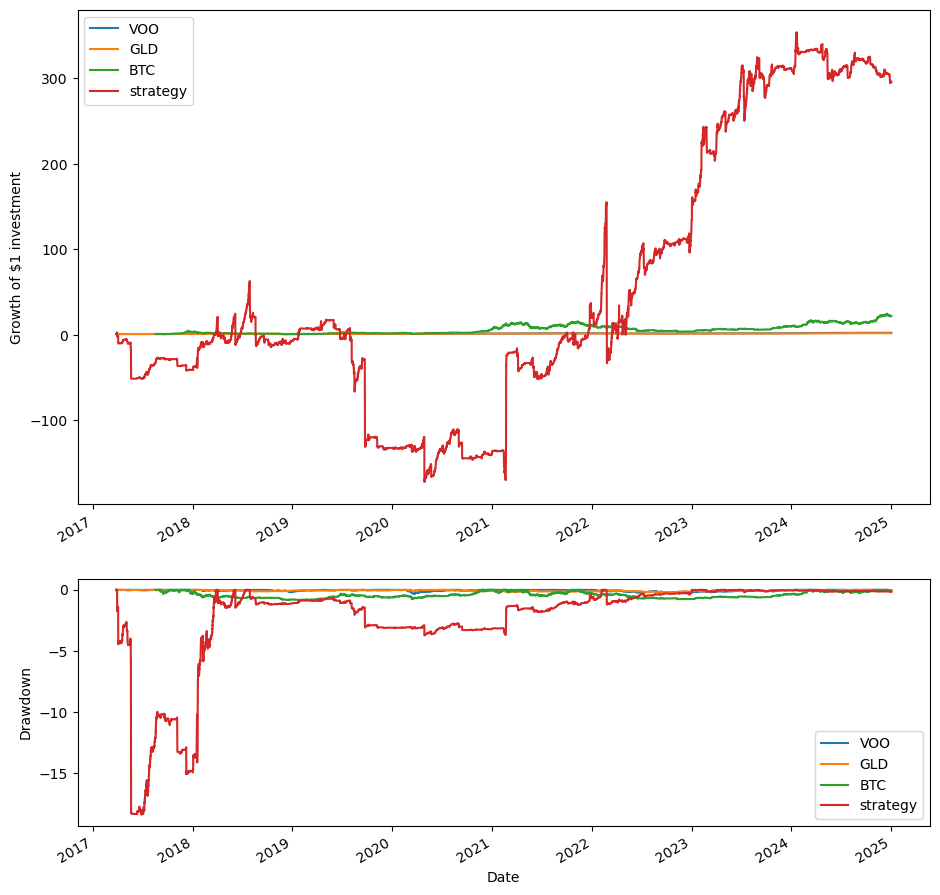

In [200]:
res_dict = at.run(alpha, scale_final=False)

0.4672894821381454


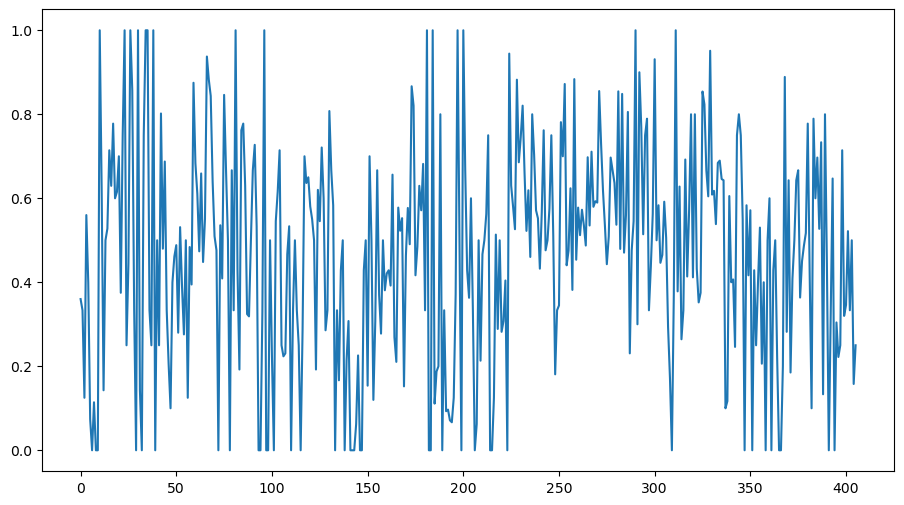

In [202]:
arr = precision_arr
print(np.mean(arr))
plt.plot(arr)